In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!unzip '/content/drive/MyDrive/Teeth/Teeth_DataSet.zip' -d '/content/dataset'

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1242_0_8475.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1206_0_5730.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1241_0_7916.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1206_0_345.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1224_0_3934.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1242_0_6077.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1209_0_8925.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1249_0_4513.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1201_0_8478.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1246_0_2056.jpg  
  inflating: /content/dataset/Teeth_Dataset/Testing/Gum/g_1205_0_6215.jpg  
  inflating: /content/dataset/Teeth_Dataset/Validation/Gum/g_1203_0_8494.jpg  
  inflating: /content/dataset/Teeth

In [7]:
#Libraries used:

import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import os

In [8]:
#Configuration

mixed_precision.set_global_policy('mixed_float16') #Using both 16-bit and 32-bit floating-points in a model to make training faster and use less memory

img_size = (224,224)
img_shape = (224,224,3)
batch = 64
epochs = 30
fine_tune_epochs = 15

train = '/content/dataset/Teeth_Dataset/Training'
test = '/content/dataset/Teeth_Dataset/Testing'
val = '/content/dataset/Teeth_Dataset/Validation'

In [9]:
#Data Pipeline

train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    image_size = img_size,
    batch_size = batch
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test,
    image_size = img_size,
    batch_size = batch,
    shuffle = False
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val,
    image_size = img_size,
    batch_size = batch
)

class_names = train_ds.class_names
num_classes = len(class_names)

print('Classes: ', class_names)


data_augmenation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
])

def preprocess (image, label, training = False):

  if training:
    image = data_augmenation(image)
  image = preprocess_input(image)
  return image, label

train_ds = train_ds.map(lambda x, y: preprocess(x, y, training=True))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, training=False))
test_ds = test_ds.map(lambda x, y: preprocess(x, y, training=False))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3087 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.
Found 1028 files belonging to 7 classes.
Classes:  ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [10]:
#Class Weights

class_counts = {}
for idx in range(len(class_names)):
    cls_path = os.path.join(train, class_names[idx])
    class_counts[idx] = len(os.listdir(cls_path))

total_images = sum(class_counts.values())

class_weights = {}
for label in class_counts:
    class_weights[label] = total_images / (num_classes * class_counts[label])

print('Class weights:', class_weights)


Class weights: {0: 0.91875, 1: 0.98, 2: 1.225, 3: 0.8166666666666667, 4: 1.3611111111111112, 5: 0.8166666666666667, 6: 1.1221374045801527}


In [11]:
# Base Model (ResNet50 pretrained back-bone + custom trained head)

base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = img_shape
)

base_model.trainable= False #Freezing the backbone

inputs = layers.Input(shape = img_shape)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, output)

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
#Training head only

callbacks_phase_1  = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor = 0.5, patience=3)
]

history_1 = model.fit (
    train_ds,
    validation_data = val_ds,
    epochs = epochs,
    class_weight = class_weights,
    callbacks = callbacks_phase_1
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.4380 - loss: 1.6271 - val_accuracy: 0.6936 - val_loss: 0.8780 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6615 - loss: 0.9251 - val_accuracy: 0.8016 - val_loss: 0.6396 - learning_rate: 0.0010
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7396 - loss: 0.7214 - val_accuracy: 0.8405 - val_loss: 0.4991 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7995 - loss: 0.5542 - val_accuracy: 0.8852 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8367 - loss: 0.4602 - val_accuracy: 0.8813 - val_loss: 0.3555 - learning_rate: 0.0010
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8533 - loss: 0.4302 - val_accuracy: 0.8969 - val_loss: 0.3181 - learning_rate: 0.0010
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.8733 - loss: 0.3389 - val_acc

In [13]:
#Fine-Tuning (Unfreezing top layers of resnet50)
#Note: We unfreeze all layers expect the last 30 for fine tuning, it keeps low level imagenet features and trains on high level features


base_model.trainable = True

fine_tune = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune]:
  layers.trainable = False


model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'sparse_categorical_crossentropy',
    metrics =['accuracy']
)

callbacks_phase_2 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]


history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks_phase_2
)

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.6084 - loss: 1.7310 - val_accuracy: 0.9484 - val_loss: 0.1377 - learning_rate: 1.0000e-05
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.8079 - loss: 0.6033 - val_accuracy: 0.9397 - val_loss: 0.1942 - learning_rate: 1.0000e-05
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.8983 - loss: 0.2670 - val_accuracy: 0.9494 - val_loss: 0.1718 - learning_rate: 1.0000e-05
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.9339 - loss: 0.1654 - val_accuracy: 0.9446 - val_loss: 0.1632 - learning_rate: 1.0000e-05
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.9563 - loss: 0.1235 - val_accuracy: 0.9348 - val_loss: 0.1716 - learning_rate: 5.0000e-06
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.9676 - loss: 0.0960 - val_accuracy: 0.9300 - val_loss: 0.1837 - learning_rate: 5.0000e-06


17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.9553 - loss: 0.1460
Test loss: 0.14595560729503632  |  Test accuracy: 0.9552529454231262
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 386ms/step
              precision    recall  f1-score   support

         CaS       0.93      0.99      0.96       160
         CoS       0.96      1.00      0.98       149
         Gum       0.99      0.97      0.98       120
          MC       0.99      0.88      0.93       180
          OC       0.86      1.00      0.92       108
         OLP       0.97      0.93      0.95       180
          OT       0.99      0.95      0.97       131

    accuracy                           0.96      1028
   macro avg       0.95      0.96      0.96      1028
weighted avg       0.96      0.96      0.96      1028



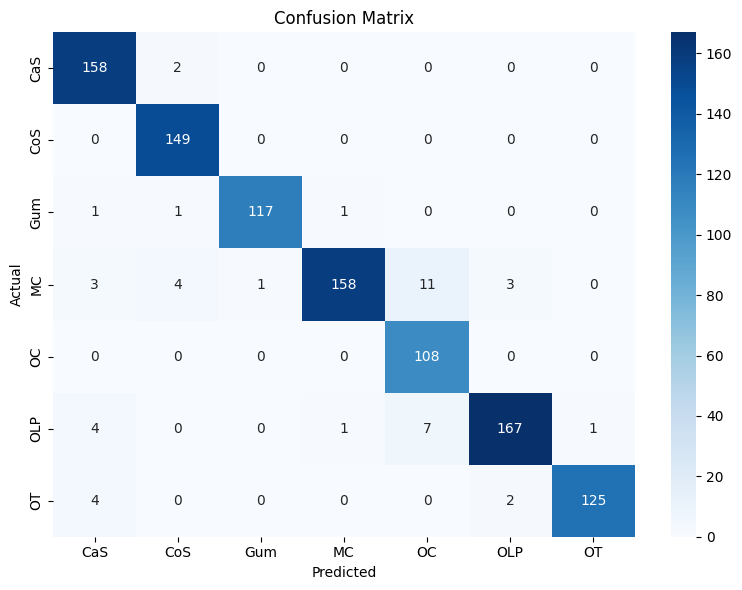

In [14]:
#Test

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss}  |  Test accuracy: {test_acc}")

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true,y_pred, target_names = class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = class_names, yticklabels = class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
#Compare with last week results

week3_results = {
    'Model' : 'Custom Resnet18 made from scratch no pretrained weights',
    'Test Accuracy' : 0.833,
    'Test Loss' : 0.440
}

week4_results = {
    'Model' : 'Resnet50 using transfer learning and fine tuning',
    'Test Accuracy' : 0.9553,
    'Test Loss' : 0.1460
}


print('Model Comparision')
print(f'Model: {week3_results['Model']} , Test Accuracy: {week3_results['Test Accuracy']}, Test Loss: {week3_results['Test Loss']}')
print(f'Model: {week4_results['Model']} , Test Accuracy: {week4_results['Test Accuracy']}, Test Loss: {week4_results['Test Loss']}')

Model Comparision
Model: Custom Resnet18 made from scratch no pretrained weights , Test Accuracy: 0.833, Test Loss: 0.44
Model: Resnet50 using transfer learning and fine tuning , Test Accuracy: 0.9553, Test Loss: 0.146


In [ ]:
print(model.name)

functional_6


In [17]:
# Save model and class names for Streamlit deployment
model.save('teeth_resnet50_model.keras')

with open('class_names.txt', 'w') as f:
    f.write('\n'.join(class_names))

print("Saved: teeth_resnet50_model.keras, class_names.txt")

# Optional: copy to Google Drive so files persist after the Colab session ends
import shutil
shutil.copy('teeth_resnet50_model.keras', '/content/drive/MyDrive/Teeth/teeth_resnet50_model.keras')
shutil.copy('class_names.txt', '/content/drive/MyDrive/Teeth/class_names.txt')
print("Copied to Google Drive.")

Saved: teeth_resnet50_model.keras, class_names.txt
Copied to Google Drive.
